Goal

Identify customers that should be prioritized for retention by combining Customer Lifetime Value (CLTV) and Churn Risk.

Business Question

Given a limited retention budget, which customers provide the highest expected return from retention efforts?

In [12]:
import pandas as pd

master_df = pd.read_csv("../data/processed/master_df.csv")

In [13]:
master_df.columns.tolist()

['Customer ID',
 'Gender',
 'Age',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Number of Dependents',
 'Referred a Friend',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Customer Status',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Category',
 'Churn Reason',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude']

In [14]:
master_df["Total Revenue"].describe()

count     7043.000000
mean      3034.379056
std       2865.204542
min         21.360000
25%        605.610000
50%       2108.640000
75%       4801.145000
max      11979.340000
Name: Total Revenue, dtype: float64

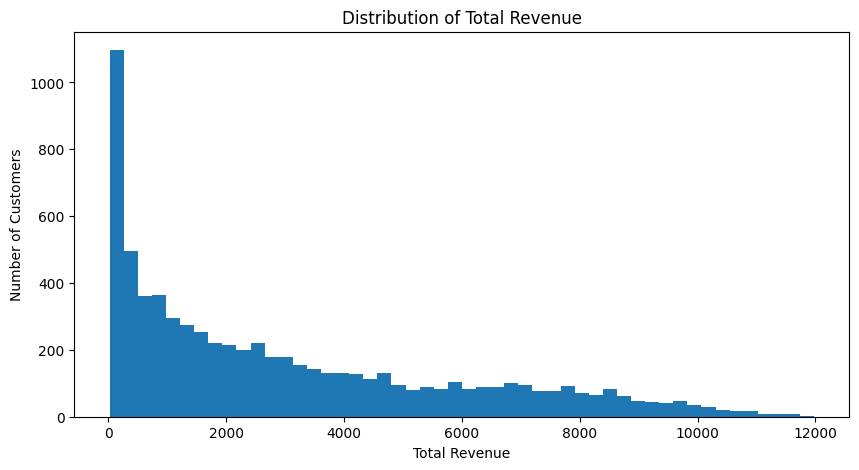

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(master_df["Total Revenue"], bins=50)
plt.title("Distribution of Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
master_df["Total Revenue"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25      605.6100
0.50     2108.6400
0.75     4801.1450
0.90     7642.8060
0.95     8747.0410
0.99    10385.6178
Name: Total Revenue, dtype: float64

In [17]:
master_df["Value Segment"] = pd.qcut(
    master_df["Total Revenue"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

In [18]:
master_df["Value Segment"].value_counts()

Value Segment
Low Value       1761
Medium Value    1761
VIP             1761
High Value      1760
Name: count, dtype: int64

In [19]:
master_df.groupby("Value Segment")["Total Revenue"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Value Segment,,,
Low Value,1761,230.383941,182.470
Medium Value,1761,1282.307183,1242.700
High Value,1760,3304.173625,3198.145
VIP,1761,7320.804679,7134.510


In [20]:
value_churn = (
    master_df
    .groupby("Value Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Revenue=("Total Revenue", "mean"),
        Churn_Rate=("Churn Value", "mean")
    )
)

value_churn["Churn_Rate"] = value_churn["Churn_Rate"] * 100

value_churn

,Customers,Avg_Revenue,Churn_Rate
Value Segment,,,
Low Value,1761,230.383941,45.599091
Medium Value,1761,1282.307183,27.030097
High Value,1760,3304.173625,18.693182
VIP,1761,7320.804679,14.821124


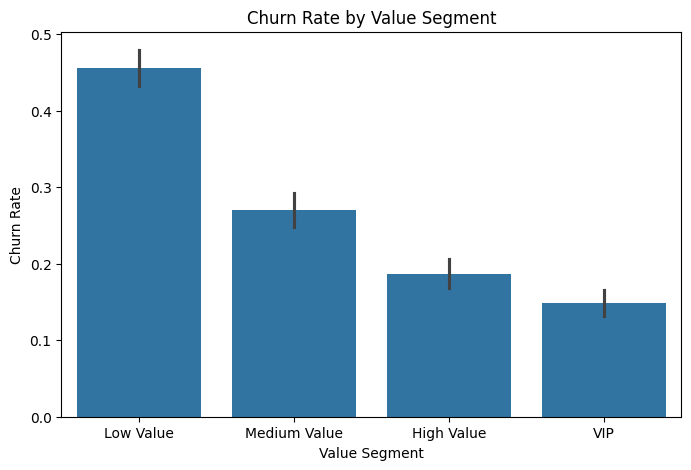

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=master_df,
    x="Value Segment",
    y="Churn Value"
)

plt.title("Churn Rate by Value Segment")
plt.ylabel("Churn Rate")
plt.show()

In [22]:
value_churn["Revenue_At_Risk"] = (
    value_churn["Customers"]
    * value_churn["Avg_Revenue"]
    * (value_churn["Churn_Rate"] / 100)
)

value_churn

,Customers,Avg_Revenue,Churn_Rate,Revenue_At_Risk
Value Segment,,,,
Low Value,1761,230.383941,45.599091,1.849983e+05
Medium Value,1761,1282.307183,27.030097,6.103782e+05
High Value,1760,3304.173625,18.693182,1.087073e+06
VIP,1761,7320.804679,14.821124,1.910730e+06


In [23]:
value_churn.sort_values(
    "Revenue_At_Risk",
    ascending=False
)

,Customers,Avg_Revenue,Churn_Rate,Revenue_At_Risk
Value Segment,,,,
VIP,1761,7320.804679,14.821124,1.910730e+06
High Value,1760,3304.173625,18.693182,1.087073e+06
Medium Value,1761,1282.307183,27.030097,6.103782e+05
Low Value,1761,230.383941,45.599091,1.849983e+05


In [24]:
master_df[
    [
        "Monthly Charge",
        "Tenure in Months",
        "Total Revenue"
    ]
].describe()

,Monthly Charge,Tenure in Months,Total Revenue
count,7043.000000,7043.000000,7043.000000
mean,64.761692,32.386767,3034.379056
std,30.090047,24.542061,2865.204542
min,18.250000,1.000000,21.360000
25%,35.500000,9.000000,605.610000
50%,70.350000,29.000000,2108.640000
75%,89.850000,55.000000,4801.145000
max,118.750000,72.000000,11979.340000


In [25]:
master_df[
    [
        "Monthly Charge",
        "Tenure in Months",
        "Total Revenue"
    ]
].corr()

,Monthly Charge,Tenure in Months,Total Revenue
Monthly Charge,1.000000,0.247582,0.588887
Tenure in Months,0.247582,1.000000,0.853146
Total Revenue,0.588887,0.853146,1.000000


In [26]:
churned_customers = master_df[master_df["Churn Value"] == 1]

churned_customers["Tenure in Months"].describe()

count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: Tenure in Months, dtype: float64

In [27]:
churned_customers["Tenure in Months"].median()

np.float64(10.0)

In [29]:
master_df["Estimated_CLTV"] = (
    master_df["Monthly Charge"]
    * master_df["Tenure in Months"]
)

master_df[
    ["Estimated_CLTV", "Total Revenue"]
].corr()

,Estimated_CLTV,Total Revenue
Estimated_CLTV,1.00000,0.97194
Total Revenue,0.97194,1.00000
